<a href="https://colab.research.google.com/github/AlexanderEgorovNRNUMEPHI/AIM-projects/blob/main/HW1(PyTorch)_Alexander_Egorov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое задание 1. Обучение полносвязной нейронной сети.

In [ ]:
import numpy as np
import pandas as pd
import torch
import cv2

from glob import glob
from collections import OrderedDict
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches

from torch import nn
from torch.autograd import Function
from torch.autograd import gradcheck
from torch.optim import Optimizer, Adam
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision import transforms

## 1. Загрузка данных (0 баллов)

Если вам требуется работать с каким-нибудь набором данных (dataset), то, прежде всего, проверьте, нет ли его среди встроенных наборов данных https://pytorch.org/vision/stable/datasets.html.

В текущем домашнем задании мы будем работать с набором данных FashionMNIST. Он присутствует в списке встроенных наборов данных, однако мы воспользуемся реализацией только для удобного и быстрого способа скачать наборы данных. Ниже предлагается реализовать собственный класс для считывания, обработки и упаковки данных.

In [ ]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True
)

Воспользуемся функцией загрузки данных из репозитория наборов данных.

In [ ]:
#! dir data\FashionMNIST\raw

In [ ]:
! ls data\FashionMNIST\raw

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
#https://github.com/zalandoresearch/fashion-mnist/blob/master/utils/mnist_reader.py

def load_mnist(path, kind='train'):
    import os
    import gzip
    import numpy as np

    """Load MNIST data from `path`"""
    labels_path = os.path.join(path,
                               '%s-labels-idx1-ubyte.gz'
                               % kind)
    images_path = os.path.join(path,
                               '%s-images-idx3-ubyte.gz'
                               % kind)

    with gzip.open(labels_path, 'rb') as lbpath:
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8,
                               offset=8)

    with gzip.open(images_path, 'rb') as imgpath:
        images = np.frombuffer(imgpath.read(), dtype=np.uint8,
                               offset=16).reshape(len(labels), 784)

    return images, labels

Для удобства PyTorch предоставляет ряд базовых классов `Dataset, DataLoader`, от которых предлагается отнаследоваться при разработке пользовательских классов. Базовый класс `Dataset` используется для загрузки и обработки данных, класс `DataLoader` используется для управления процессом загрузки данных, позволяет в многопоточном режиме загружать данные и упаковывать их.
Эти вспомогательные классы находятся в модуле `torch.utils.data`.

При наследовании от класса `torch.utils.data.Dataset` требуется переопределить метод `__len__`, который возвращает количество примеров в наборе данных, а также метод `__getitem__`, который позволяет получить доступ к примеру из набора данных по индексу.

Реализуем класс для FasionMnist.

Элементами датасета должны являться пары '(np.array, int)', массив имеет размерность `(28, 28)`, тип элемента `np.float32`.

In [ ]:
import os

class FashionMnist(Dataset):
    def __init__(self, path, train=True, image_transform=None,
                 label_transform=None):
        if train:
            images, labels = load_mnist(os.path.join(path,"raw"))
        else:
            images, labels = load_mnist(os.path.join(path,"raw"), kind="t10k")

        if image_transform is not None:
            images = image_transform(np.array(images))
        if label_transform is not None:
            labels = image_transform(np.array(labels))

        if len(images) != len(labels):
            raise ValueError(f"lens mismatch {len(images)} != {len(labels)}")

        self.images = images
        self.labels = labels

    def __len__(self,):
        length = len(self.images)
        return length

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        return img, label


In [ ]:
test_dataset = FashionMnist("data/FashionMNIST", train=False)
train_dataset = FashionMnist("data/FashionMNIST")

Визуализируйте случайные элементы набора данных.

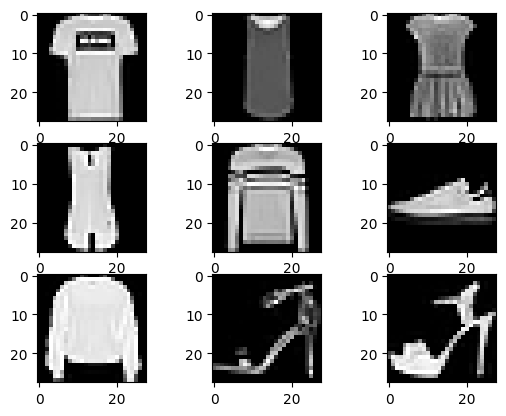

In [ ]:
for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(train_dataset[i][0].reshape(28, 28), cmap=plt.get_cmap('gray'))

plt.show()

В конструктор `Dataset` можно передать объект `torchvision.transforms`, который позволяет преобразовать исходные данные. Преобразование `torchvision.transforms.ToTensor` позволяет преобразоать данные из типа `PIL Image` и `numpy.float32` в тип `torch.float32`

Реализуйте собственную поддержку преобразований в `FashionMnist`. Проверьте, что приведение типов работает корректно.

In [ ]:
class ToTensor:
    """Convert ndarrays in sample to Tensors."""

    def __call__(self, sample):
        return torch.from_numpy(sample)

In [ ]:
transform = ToTensor()

test_dataset = FashionMnist("data/FashionMNIST",
                            train=False,
                            image_transform=transform,
                            label_transform=transform
                            )
train_dataset = FashionMnist("data/FashionMNIST",
                             image_transform=transform,
                             label_transform=transform
                             )

In [ ]:
import datetime

datetime.datetime.today()

datetime.datetime(2024, 10, 13, 19, 42, 46, 355544)

In [ ]:
print(f"The type of the data is {type(test_dataset[0][0])}")

The type of the data is <class 'torch.Tensor'>


Элементы набора данных могут быть объединены в пакеты (batch) явно и неявно. Если данные могут быть сконкатенированы или обЪединены каким-нибудь тривиальным способом, то можно не передавать никаких дополнительных парамертов в `torch.utils.data.Dataloader`.

In [ ]:
test_dataloader = DataLoader(test_dataset, batch_size=15, num_workers=0, shuffle=True)
batch = next(iter(test_dataloader))

In [ ]:
batch[0].shape

torch.Size([15, 784])

In [ ]:
print(f"The length of the batch is {len(batch)}")
print(f"The shape of the batch[0] is {batch[0].shape}")

The length of the batch is 2
The shape of the batch[0] is torch.Size([15, 784])


Однако, если наша структура данных не позволяет нам использовать объединение по умолчанию, то можно написать собственную функцию, которая будет пакетировать данные.

Реализуйте функцию, преобразующую последовательность элементов массива в пакет (batch).

In [ ]:
def collate(batch):
    imgs = torch.zeros(len(batch), batch[0][0].shape[0])
    labels = torch.zeros(len(batch))

    for idx, tens in enumerate(batch):
        imgs[idx] = tens[0]
        labels[idx] = tens[1]

    return imgs, labels

Убедитесть, что все работает корректно.

In [ ]:
test_dataloader = DataLoader(test_dataset, batch_size=15, num_workers=0,
                             shuffle=True, collate_fn=collate)
train_dataloader = DataLoader(train_dataset, batch_size=15, num_workers=0,
                              shuffle=True, collate_fn=collate)
batch = next(iter(test_dataloader))

In [ ]:
print(f"The length of the batch is {len(batch)}")
print(f"The shape of the batch[0] is {batch[0].shape}")

The length of the batch is 2
The shape of the batch[0] is torch.Size([15, 784])


## 2. Реализация модулей нейронной сети (15 баллов)

В этом разделе мы полностью реализуем модули для полносвязанной сети.

Для начала нам понадобится реализовать прямой и обратный проход через слои.

Наши слои будут соответствовать следующему интерфейсу (на примере "тождественного" слоя):

Сначала, мы реализуем функцию и её градиент.

In [ ]:
class IdentityFunction(Function):
    """
    We can implement our own custom autograd Functions by subclassing
    torch.autograd.Function and implementing the forward and backward passes
    which operate on Tensors.
    """
    @staticmethod
    def forward(ctx, input):
        """
        In the forward pass we receive a Tensor containing the input and return
        a Tensor containing the output. ctx is a context object that can be used
        to stash information for backward computation. You can cache arbitrary
        objects for use in the backward pass using the ctx.save_for_backward method.
        """
        return input

    @staticmethod
    def backward(ctx, grad_output):
        """
        In the backward pass we receive a Tensor containing the gradient of the loss
        with respect to the output, and we need to compute the gradient of the loss
        with respect to the input.
        """
        return grad_output

Разработанную функцию обернем классом `IdentityLayer`, все слои в `PyTorch` должны быть наследниками базового класса `nn.Module()`


In [ ]:
class IdentityLayer(nn.Module):
    def __init__(self):
        # An identity layer does nothing
        super().__init__()
        self.identity = IdentityFunction.apply

    def forward(self, inp):
        # An identity layer just returns whatever it gets as input.
        return self.identity(inp)


### 2.1 Функция активации ReLU (1 балл)
Для начала реализуем функцию активации, слой нелинейности `ReLU(x) = max(x, 0)`. Параметров у слоя нет. Метод `forward` должен вернуть результат поэлементного применения `ReLU` к входному массиву, метод `backward` - градиент функции потерь по входу слоя. В нуле будем считать производную равной 0. Обратите внимание, что при обратном проходе могут понадобиться величины, посчитанные во время прямого прохода, поэтому их стоит сохранить в `ctx`.

In [ ]:
class ReLUFunction(Function):
    @staticmethod
    def forward(ctx, input):
        relu = torch.maximum(input, torch.as_tensor(0))
        ctx.save_for_backward(relu)
        return relu

    @staticmethod
    def backward(ctx, grad_output):
        relu, = ctx.saved_tensors
        relu = relu.clone().detach()
        relu[relu!=0] = 1
        return grad_output * relu


In [ ]:
class ReLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.identity = ReLUFunction.apply


    def forward(self, input):
        return self.identity(input)

Не забываем после реализации функции проверить градиент, испльзуя функцию `gradcheck`.

In [ ]:
x = torch.rand(5, requires_grad=True).double()

relu = ReLU()

assert gradcheck(relu.to(dtype=torch.float64), x)

In [ ]:
x = torch.rand(5).double()
torch_relu = nn.ReLU()
our_relu = ReLU()

assert torch.norm(torch_relu(x.float()) - our_relu(x)) < 1e-5

### 2.2 Линейный слой (linear, fully-connected) (3 балла)
Далее реализуем полносвязный слой без нелинейности. У слоя два набора параметра: матрица весов (weights) и вектор смещения (bias).

In [ ]:
class LinearFunction(Function):
    @staticmethod
    def forward(ctx, inp, weight, bias):
        ctx.save_for_backward(inp, weight)
        output = inp@(weight.T) + bias
        return output
    @staticmethod
    def backward(ctx, grad_output):
        inp, weight = ctx.saved_tensors
        return grad_output @ weight, grad_output.T @ inp, grad_output

In [ ]:
class Linear(nn.Module):
    def __init__(self, input_units, output_units):
        super().__init__()
        # initialize weights with small random numbers from normal distribution

        self.weight = nn.Parameter(torch.randn(output_units, input_units) / torch.sqrt(torch.tensor(input_units, dtype=torch.float32)))
        self.bias = nn.Parameter(torch.randn(output_units).float())
        self.identity = LinearFunction.apply

        # k = np.sqrt(1/input_units)
        # self.weight = nn.Parameter(torch.FloatTensor(output_units, input_units).uniform_(-k, k))
        # self.bias = nn.Parameter(torch.FloatTensor(output_units).uniform_(-k, k))

    def forward(self,inp):

        return self.identity(inp, self.weight, self.bias)


Проверим градиент, а также сравним с работой нашего модуля с имплементированным в `PyTorch`.

Проверка градиента:

In [ ]:
x = torch.rand((3,5), requires_grad=True).double()
weight = torch.randn((8,5), requires_grad=True).double()
bias = torch.randn((8), requires_grad=True).double()
linear = LinearFunction.apply

print(gradcheck(linear, (x, weight, bias), eps=1e-4, atol=1e-3))

True


Сравнение с `PyTorch`.

In [ ]:
x = torch.rand((3,5))
torch_linear = nn.Linear(5, 8)
our_linear = Linear(input_units=5, output_units=8)

state_dict = our_linear._parameters
torch_linear.load_state_dict(state_dict)
our_linear.load_state_dict(state_dict)

assert torch.norm(torch_linear(x.float()) - our_linear(x)) < 1e-5


### 2.3 LogSoftmax (Log + Softmax) (4 балла)

Для решения задачи многоклассовой классификации обычно используют `softmax` в качестве нелинейности на последнем слое, чтобы получить "оценку" вероятности классов для каждого объекта:$$\hat y = softmax(x)  = \bigl \{\frac {exp(x_i)}{\sum_j exp(x_j)} \bigr \}_{i=1}^K, \quad K - \text{число классов}$$В этом случае удобно оптимизировать логарифм правдоподобия:$$L(y, \hat y) = -\sum_{i=1}^K y_i \log \hat y_i \rightarrow \min,$$где $y_i=1$, если объект принадлежит $i$-му классу, и 0 иначе. Записанная в таком виде, эта функция потерь совпадает с выражением для кросс-энтропии. Очевидно, что ее также можно переписать через индексацию, если через $y_i$ обозначить класс данного объекта:$$L(y, \hat y) = - \log \hat y_{y_i} \rightarrow \min$$В таком виде ее удобно реализовывать.

Реализуйте слой `LogSoftmax` (без параметров). Метод `forward` должен вычислять логарифм от `softmax`, а метод `backward` - пропускать градиенты. В общем случае в промежуточных вычислениях `backward` получится трехмерный тензор, однако для нашей конкретной функции потерь все вычисления можно реализовать в матричном виде. Поэтому мы будем предполагать, что аргумент `grad_output` - это матрица, у которой в каждой строке только одно ненулевое значение (не обязательно единица).

Для полного балла нужна имплементация с `Log-Sum-Exp trick`.

In [ ]:
dim = 1 # Направление расчета logsoftmax. 0 - по строкам, 1 - по столбцам. По заданию LogSoftmax должен быть без параметров,
# поэтому вынес как глобальную переменную. Лучше сделать через параметр как в реализации torch

class LogSoftmaxFunction(Function):
    @staticmethod
    def forward(ctx, inp):
        c = torch.max(inp, dim, keepdims=True).values
        LSE = c + torch.log(torch.sum(torch.exp(inp - c), dim, keepdims=True))
        log_softmax = inp - LSE
        ctx.save_for_backward(log_softmax)
        return log_softmax

    @staticmethod
    def backward(ctx, grad_output):
        log_softmax, = ctx.saved_tensors
        idx = grad_output.nonzero(as_tuple=True)
        grad = torch.zeros(grad_output.shape).to(log_softmax.device)
        if dim == 0:
            grad[:, idx[1]] += torch.exp(log_softmax)[:, idx[1]]
        elif dim == 1:
            grad[idx[0], :] += torch.exp(log_softmax)[idx[0],: ]
        else:
            raise ValueError("dim must be 0 or 1")
        if grad_output[grad_output<0].any():
            grad = -grad
        return grad_output - grad



In [ ]:
class LogSoftmax(nn.Module):
    def __init__(self):
        super().__init__()
        self.identity = LogSoftmaxFunction.apply

    def forward(self, input):
        return self.identity(input)

Проверка градиентов.

In [ ]:
x = torch.rand((3,5), requires_grad=True).double().to("cuda")

logsoftmax = LogSoftmax()

print(gradcheck(logsoftmax.to(dtype=torch.float64), x, eps=1e-4, atol=1e-3))

True


In [ ]:
x = torch.rand((3,3), requires_grad=True).double()
torch_logsoftmax = nn.LogSoftmax(1)
logsoftmax = LogSoftmax()

assert torch.norm(torch_logsoftmax(x.float()) - logsoftmax(x)) < 1e-5

### 2.4 Dropout (2 балла)
Реализуйте слой Dropout.

In [ ]:
class DropoutFunction(Function):
    @staticmethod
    def forward(ctx, inp, p, training):
        if training:
            binomial_mask = torch.distributions.binomial.Binomial(probs=1-p).sample(inp.size()).to(inp.device)
            ctx.save_for_backward(binomial_mask)
            return inp * binomial_mask * (1/(1-p+torch.finfo(float).eps))
        return inp

    @staticmethod
    def backward(ctx, grad_output):
        binomial_mask, = ctx.saved_tensors
        return grad_output * binomial_mask, None, None


In [ ]:
class Dropout(nn.Module):
    def __init__(self, p, training=True):
        super().__init__()
        self.p = p
        self.training  = training
        self.identity = DropoutFunction.apply

    def forward(self, input):
        return self.identity(input, self.p, self.training)

In [ ]:
x = torch.rand((3,5), requires_grad=True).double()

dropout = Dropout(p=0.5)
dropout(x)

tensor([[0.0000, 0.0000, 0.0000, 1.0084, 0.1993],
        [0.3333, 0.0000, 0.0791, 0.2426, 0.0000],
        [1.4462, 0.3119, 0.9528, 0.0000, 1.5940]], dtype=torch.float64,
       grad_fn=<DropoutFunctionBackward>)

### 2.5 CrossEntropy (5 баллов)

При решении задачи многоклассовой классификации мы будет использовать в качестве функции потерь **кроссэнтропию, совместимую с `LogSoftmax` активацией**.

Реализуйте эту функцию потерь. В разделе 2.3 приведены полезные формулы.

In [ ]:
dim = 1

class CrossEntropyFunction(Function):
    @staticmethod
    def forward(ctx, activations, target):
        ctx.save_for_backward(activations, target)
        return -sum([activations[idx][i] for idx,
                     i in enumerate(target)])

    @staticmethod
    def backward(ctx, grad_output):
        activations, target = ctx.saved_tensors
        grad = torch.nn.functional.one_hot(target,
                                            num_classes=activations.shape[1])
        return -grad*grad_output, None

class CrossEntropy(nn.Module):
    def __init__(self, ):
        super().__init__()
        self.identity = CrossEntropyFunction.apply

    def forward(self, activations, target):
        return self.identity(activations, target)

In [ ]:
torch_cross_entropy_loss = nn.CrossEntropyLoss(reduction="sum")
input = torch.randn(3, 5, requires_grad=True)
target = torch.empty(3, dtype=torch.long).random_(5)

dim = 1
cross_entropy = CrossEntropy()
logsoftmax = LogSoftmax()
logsoftmax_torch = nn.LogSoftmax(dim=1)
assert torch.norm(torch_cross_entropy_loss(logsoftmax_torch(input), target) - cross_entropy(logsoftmax(input), target)) < 1e-5


Проверка градиентов.

In [ ]:
input = torch.randn(3, 5, requires_grad=True).double()
target = torch.empty(3, dtype=torch.long).random_(5)

dim = 1
cross_entropy = CrossEntropy()
print(gradcheck(cross_entropy.to(dtype=torch.float64), (input, target), eps=1e-4, atol=1e-3))

True


## 3. Сборка и обучение нейронной сети (5 баллов)

Реализуйте из ваших блоков персептрон и обучите его, залоггировав итоговый лосс и метрику на валидационной выборке. **(1 балл)**

Подсказка: вытягиваем картинку в вектор с помощью [nn.Flatten](https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html)

In [ ]:
class Network(nn.Module):
    def __init__(self, input_size=28*28, hidden_layers_size=32, num_layers=5,
                 num_classes=10,
                 p=0.1):
        super().__init__()
        self.perceptron = nn.Sequential(
            nn.Flatten(),
            Linear(input_size, hidden_layers_size),
            ReLU(),
            *[Linear(hidden_layers_size, hidden_layers_size),
            ReLU()] * (num_layers-2),
            Dropout(p),
            Linear(hidden_layers_size, num_classes),
            LogSoftmax(),
        )

    def forward(self, inp):
        return self.perceptron(inp)

    def predict(self, inp):
        return self.forward(inp).argmax(dim=1)


Ниже приведены функции, реализующие обучение нейронной сети. В данном задании их предлагается просто переиспользовать.

In [ ]:
class EmptyContext:
    def __enter__(self):
        pass

    def __exit__(self, *args):
        pass

In [ ]:
# accuracy metric for our classififcation
def accuracy(model_labels, labels):
  return torch.mean((model_labels == labels).float())

In [ ]:
def perform_epoch(model, loader, criterion,
                optimizer=None, device=None):
    is_train = optimizer is not None
    model = model.to(device)
    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0
    total_acc = 0
    total_n = 0
    with EmptyContext() if is_train else torch.no_grad():
        for batch_data, batch_labels in loader:
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)
            model_labels = model(batch_data)
            model_prediction = model.predict(batch_data)
            new_loss = criterion(model_labels, batch_labels.long())
            if is_train:
              optimizer.zero_grad()
              new_loss.backward()
              optimizer.step()

            one_batch_loss = float(criterion(model_labels, batch_labels.long()))
            one_batch_acc = accuracy(model_prediction, batch_labels.long())

            total_loss += one_batch_loss
            total_acc += one_batch_acc
            total_n += 1
    return (total_loss / total_n, total_acc / total_n)

Теперь обучим нашу нейронную сеть. В данном разделе будем использовать оптимизатор `Adam` с параметрами по умолчанию.

In [ ]:
model     = Network()
optimizer = Adam(model.parameters())
criterion = CrossEntropy() #nn.NLLLoss(reduction="sum")


## GPU

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"GPU: {torch.cuda.get_device_name(0)} is available.")

model.to(device)

import time

start = time.time()
for epoch in range(10):
    loss, acc = perform_epoch(model, train_dataloader, criterion,
                                optimizer=optimizer, device=device)
    loss_test, acc_test = perform_epoch(model, test_dataloader, criterion, device=device)
    print(f"Epoch - {epoch} : train loss {loss}, train accuracy {acc}")
    print(f"Epoch - {epoch} : test loss {loss_test}, test accuracy {acc_test}")
    print(f"Current learning rate: {optimizer.param_groups[0]['lr']}")

print(f"Elapsed time: {time.time() - start} seconds")

GPU: NVIDIA GeForce RTX 4070 Laptop GPU is available.
Epoch - 0 : train loss 9.89699103963375, train accuracy 0.7586828470230103
Epoch - 0 : test loss 10.792199387543205, test accuracy 0.7382801175117493
Current learning rate: 0.001
Epoch - 1 : train loss 9.774864947259426, train accuracy 0.7595329880714417
Epoch - 1 : test loss 9.521397912341437, test accuracy 0.769813597202301
Current learning rate: 0.001
Epoch - 2 : train loss 9.34096045422554, train accuracy 0.7729674577713013
Epoch - 2 : test loss 9.285823735161342, test accuracy 0.7802587151527405
Current learning rate: 0.001
Epoch - 3 : train loss 9.403277737945318, train accuracy 0.7680508494377136
Epoch - 3 : test loss 9.455149992295112, test accuracy 0.7686148285865784
Current learning rate: 0.001
Epoch - 4 : train loss 9.034090050727128, train accuracy 0.780333936214447
Epoch - 4 : test loss 9.349277239153231, test accuracy 0.7748611569404602
Current learning rate: 0.001
Epoch - 5 : train loss 8.953281558543443, train accura

In [ ]:
print(f"Epoch - {epoch} : loss {loss}, accuracy {acc}")
print(f"Epoch - {epoch} : test loss {loss_test}, test accuracy {acc_test}")
print(f"Current learning rate: {optimizer.param_groups[0]['lr']}")

Epoch - 9 : loss 8.601198738604785, accuracy 0.790483295917511
Epoch - 9 : test loss 9.07626729676391, test accuracy 0.7873548269271851
Current learning rate: 0.001


## CPU

In [ ]:
model     = Network()
optimizer = Adam(model.parameters())
criterion = CrossEntropy()

In [ ]:
device = "cpu"

model.to(device)
import time
loss_history = {"train": [], "test": []}
acc_history = {"train": [], "test": []}

start = time.time()
for epoch in range(10):
    loss, acc = perform_epoch(model, train_dataloader, criterion,
                                optimizer=optimizer, device=device)
    loss_test, acc_test = perform_epoch(model, test_dataloader, criterion, device=device)
    print(f"Epoch - {epoch} : train loss {loss}, train accuracy {acc}")
    print(f"Epoch - {epoch} : test loss {loss_test}, test accuracy {acc_test}")
    print(f"Current learning rate: {optimizer.param_groups[0]['lr']}")
    loss_history["train"].append(loss)
    loss_history["test"].append(loss_test)
    acc_history["train"].append(acc)
    acc_history["test"].append(acc_test)

print(f"Elapsed time: {time.time() - start} seconds")

Epoch - 0 : train loss 13.624499065726996, train accuracy 0.6738928556442261
Epoch - 0 : test loss 10.001396825109822, test accuracy 0.7315835356712341
Current learning rate: 0.001
Epoch - 1 : train loss 9.63237089240551, train accuracy 0.7337978482246399
Epoch - 1 : test loss 9.32000386160889, test accuracy 0.7415781021118164
Current learning rate: 0.001
Epoch - 2 : train loss 9.165587742984295, train accuracy 0.7431311011314392
Epoch - 2 : test loss 10.126529133480707, test accuracy 0.7309340834617615
Current learning rate: 0.001
Epoch - 3 : train loss 8.911275814890862, train accuracy 0.7497495412826538
Epoch - 3 : test loss 8.975098228883528, test accuracy 0.7455264329910278
Current learning rate: 0.001
Epoch - 4 : train loss 8.6488976547122, train accuracy 0.761766254901886
Epoch - 4 : test loss 9.003204527644739, test accuracy 0.7629674673080444
Current learning rate: 0.001
Epoch - 5 : train loss 8.47499573597312, train accuracy 0.771966814994812
Epoch - 5 : test loss 8.751889805

In [ ]:
print(f"Epoch - {epoch} : loss {loss}, accuracy {acc}")
print(f"Epoch - {epoch} : test loss {loss_test}, test accuracy {acc_test}")
print(f"Current learning rate: {optimizer.param_groups[0]['lr']}")

Epoch - 9 : loss 7.805996756196022, accuracy 0.7997351884841919
Epoch - 9 : test loss 8.717929692818844, test accuracy 0.7926522493362427
Current learning rate: 0.001


In [ ]:
from typing import Any

def plot_history(num_epochs:int, history:dict[str, list[Any]], history_name: str = "Loss") -> None:
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_epochs + 1), history["train"], label="train")
    plt.plot(range(1, num_epochs + 1), history["test"], label="test")
    plt.xlabel("Epochs", fontsize=15)
    plt.ylabel(history_name, fontsize=15)
    plt.legend()
    plt.grid()
    plt.show()

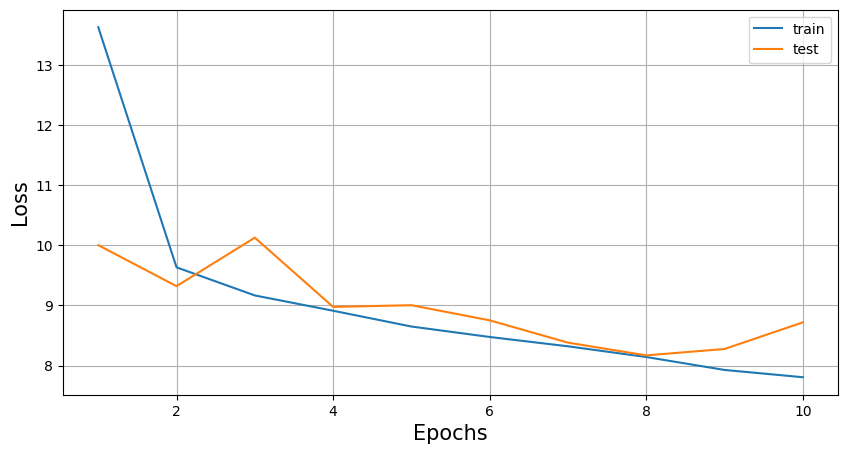

In [ ]:
plot_history(num_epochs=10, history=loss_history)

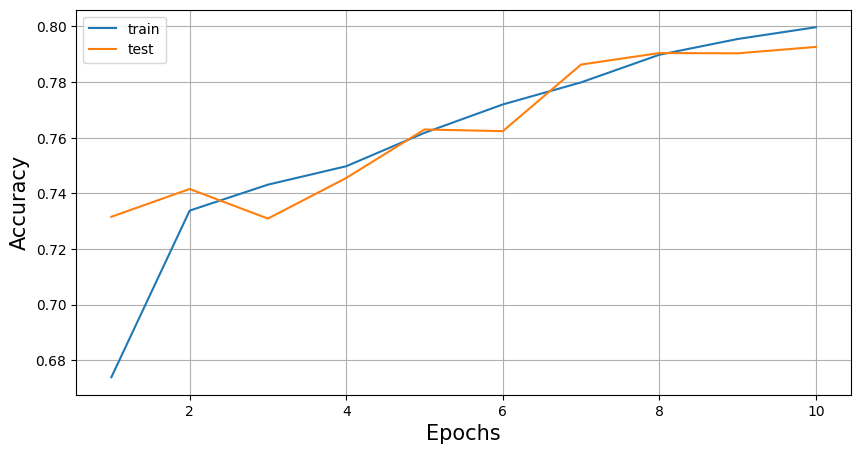

In [ ]:
plot_history(num_epochs=10, history=acc_history, history_name="Accuracy")

Дальше **(4 балла)**:
- Проведите эксперименты с числом слоев.
- Постройте графики зависимости качества модели на тренировочной и тестовой выборках от числа слоев. Для получения статистически значимых результатов повторите эксперименты несколько раз.
- Сделайте выводы.

Training Loop для выполнения этой части задания можно и нужно улучшать, в том числе, добавляя более продвинутое логгирование эксперимента.

In [ ]:
from joblib import Parallel, delayed


device = "cpu"


def get_trials():
    loss_history = {}
    acc_history = {}
    for num_layers in range(2, 11):

        model     = Network(num_layers=num_layers)
        optimizer = Adam(model.parameters())
        criterion = CrossEntropy()
        model.to(device)

        for epoch in range(10):
            loss, acc = perform_epoch(model, train_dataloader, criterion,
                                        optimizer=optimizer, device=device)
            loss_test, acc_test = perform_epoch(model, test_dataloader, criterion, device=device)

        loss_history[num_layers] = {"train_loss": loss, "test_loss": loss_test}
        acc_history[num_layers] = {"train_accuracy": acc, "test_accuracy": acc_test}

    return loss_history, acc_history




trials = Parallel(n_jobs=10)(delayed(get_trials)() for trial in range(1, 11))






In [ ]:
def loss_and_accuracy_from_trials(trials):
    loss = []
    accuracy = []
    for trial in trials:
        loss.append(pd.DataFrame(trial[0]).T)
        accuracy.append(pd.DataFrame(trial[1]).T)

    loss = pd.concat(loss, axis=1)
    accuracy = pd.concat(accuracy, axis=1).astype("float").round(2)


    return loss, accuracy

In [ ]:

loss, accuracy = loss_and_accuracy_from_trials(trials)

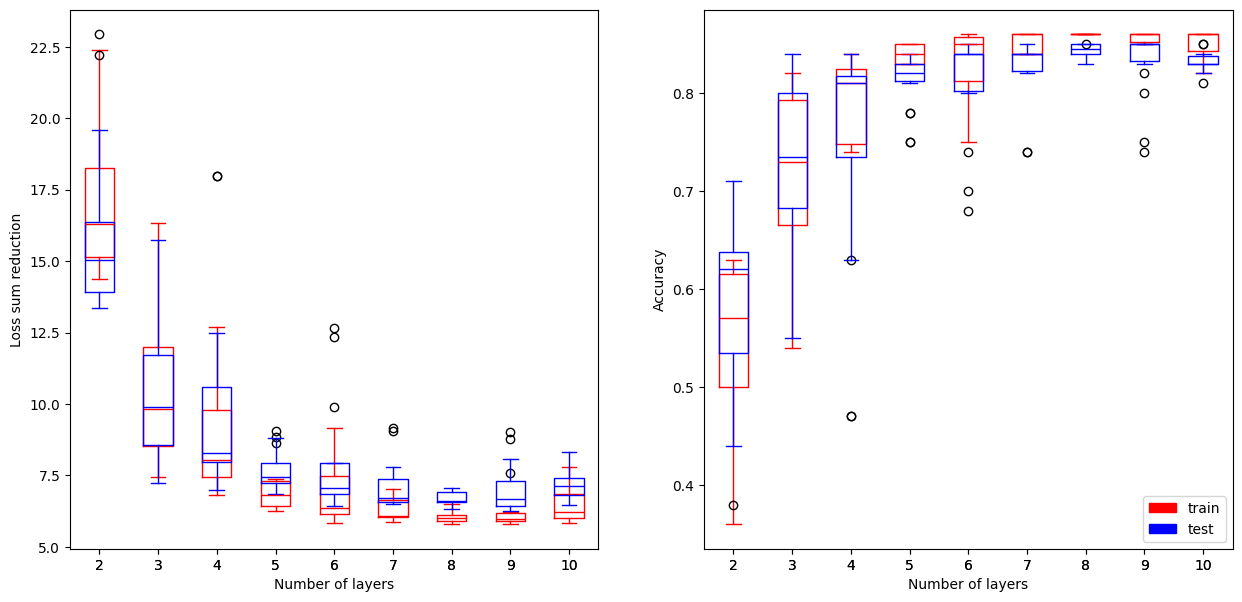

In [ ]:

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,7))
colour=['red','blue']

loss.loc[:, "train_loss"].T.plot.box(ax=ax[0],
                          color={'whiskers': colour[0],
                                 'caps': colour[0],
                                 'medians': colour[0],
                                 'boxes': colour[0]}
                          )

loss.loc[:, "test_loss"].T.plot.box(ax=ax[0],
                          color={'whiskers': colour[1],
                                 'caps': colour[1],
                                 'medians': colour[1],
                                 'boxes': colour[1]}
                          )

red_patch = mpatches.Patch(color='red', label='train')
blue_patch = mpatches.Patch(color='blue', label='test')
ax[0].set_xlabel("Number of layers")
ax[0].set_ylabel("Loss sum reduction")

accuracy.loc[:, "train_accuracy"].T.plot.box(ax=ax[1],
                          color={'whiskers': colour[0],
                                 'caps': colour[0],
                                 'medians': colour[0],
                                 'boxes': colour[0]}
                          )

accuracy.loc[:, "test_accuracy"].T.plot.box(ax=ax[1],
                          color={'whiskers': colour[1],
                                 'caps': colour[1],
                                 'medians': colour[1],
                                 'boxes': colour[1]}
                          )

red_patch = mpatches.Patch(color='red', label='train')
blue_patch = mpatches.Patch(color='blue', label='test')
ax[1].set_xlabel("Number of layers")
ax[1].set_ylabel("Accuracy")


plt.legend(handles=[red_patch, blue_patch])


**С ростом числа слоев дисперсия результата уменьшается и решение становится более стабильным. Точность растет, а ошибка падает. Это наглядная демонстрация пользы глубокого обучения. При этом с какого-то момента(на графике это примерно 7 слоев и выше результат на тесте начинает больше отличаться от тренировочного(эффект переобучения)). Поэтому "хорошее решение" - это баланс числа слоев и борьбы с переобучением.**

## 4. Бонусная часть.

### 4.1 Реализация метода оптимизации (3 + 3 балла).
Реализуйте сами метод оптимизации  для рассмотренной выше архитектуры. Вы можете выбрать произвольный метод от градиентного спуска до современных вариантов. Продемонстрируйте правильную работу метода оптимизации, сравните его работы с Adam.

**Дополнительные баллы** вы получите, если метод будет уникален среди сдавших задание.

При написании использовал: https://pytorch.org/docs/stable/_modules/torch/optim/sgd.html#SGD

Название параметров совпадают с https://pytorch.org/docs/stable/generated/torch.optim.RMSprop.html
(без централизации)

Везде использую 5 слоев и стартовую архитектуру сети(как в основной части)

In [ ]:
class RMSProp(Optimizer):
    def __init__(self, params, lr=1e-3, alpha=0.99, momentum=0):
        if momentum<0:
            msg = "momentum is not negative!"
            raise ValueError(msg)
        defaults = dict(lr=lr, alpha=alpha, momentum=momentum)
        super(RMSProp, self).__init__(params, defaults)

    def __setstate__(self, state):
        super(RMSProp, self).__setstate__(state)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        for group in self.param_groups:
            lr = group['lr']
            alpha = group['alpha']
            momentum = group['momentum']
            for p in group['params']:
                if p.grad is not None:
                    v = self.state[p].get('v', 0)
                    b = self.state[p].get('b', 0)
                    v = alpha * v + (1 - alpha) * torch.square(p.grad)
                    b = momentum*b + p.grad / (torch.sqrt(v) + torch.finfo(float).eps)
                    self.state[p]['v'] = v
                    self.state[p]['b'] = b
                    p.data.add_(-lr * b)
                    p.grad.data.zero_()
        return loss

In [ ]:
class Network(nn.Module):
    def __init__(self, input_size=28*28, hidden_layers_size=32, num_layers=5,
                 num_classes=10,
                 p=0.1):
        super().__init__()
        self.perceptron = nn.Sequential(
            nn.Flatten(),
            Linear(input_size, hidden_layers_size),
            ReLU(),
            *[Linear(hidden_layers_size, hidden_layers_size),
            ReLU()] * (num_layers-2),
            Dropout(p),
            Linear(hidden_layers_size, num_classes),
            LogSoftmax(),
        )

    def forward(self, inp):
        return self.perceptron(inp)

    def predict(self, inp):
        return self.forward(inp).argmax(dim=1)

In [ ]:
model     = Network()
optimizer = RMSProp(model.parameters())
criterion = CrossEntropy()

In [ ]:
device = "cpu"

model.to(device)
import time
loss_history = {"train": [], "test": []}
acc_history = {"train": [], "test": []}

start = time.time()
for epoch in range(10):
    loss, acc = perform_epoch(model, train_dataloader, criterion,
                                optimizer=optimizer, device=device)
    loss_test, acc_test = perform_epoch(model, test_dataloader, criterion, device=device)
    print(f"Epoch - {epoch} : train loss {loss}, train accuracy {acc}")
    print(f"Epoch - {epoch} : test loss {loss_test}, test accuracy {acc_test}")
    print(f"Current learning rate: {optimizer.param_groups[0]['lr']}")
    loss_history["train"].append(loss)
    loss_history["test"].append(loss_test)
    acc_history["train"].append(acc)
    acc_history["test"].append(acc_test)

print(f"Elapsed time: {time.time() - start} seconds")

Epoch - 0 : train loss 14.795183618158102, train accuracy 0.709577202796936
Epoch - 0 : test loss 8.981557613012495, test accuracy 0.8010978698730469
Current learning rate: 0.001
Epoch - 1 : train loss 8.884246342718601, train accuracy 0.7920011281967163
Epoch - 1 : test loss 9.072744040117449, test accuracy 0.7747610807418823
Current learning rate: 0.001
Epoch - 2 : train loss 8.181380678668619, train accuracy 0.8079683184623718
Epoch - 2 : test loss 7.775239289343089, test accuracy 0.8096430897712708
Current learning rate: 0.001
Epoch - 3 : train loss 7.788172091662884, train accuracy 0.8195685148239136
Epoch - 3 : test loss 8.041774501418066, test accuracy 0.8118923902511597
Current learning rate: 0.001
Epoch - 4 : train loss 7.458145675234497, train accuracy 0.8238348960876465
Epoch - 4 : test loss 7.882315223229521, test accuracy 0.8193383812904358
Current learning rate: 0.001
Epoch - 5 : train loss 7.414597443319857, train accuracy 0.830451488494873
Epoch - 5 : test loss 7.771193

In [ ]:
from joblib import Parallel, delayed


device = "cpu"
num_layers = 5

def get_trials():
    loss_history = {}
    acc_history = {}

    model     = Network()
    optimizer = RMSProp(model.parameters())
    criterion = CrossEntropy()
    model.to(device)

    for epoch in range(10):
        loss, acc = perform_epoch(model, train_dataloader, criterion,
                                    optimizer=optimizer, device=device)
        loss_test, acc_test = perform_epoch(model, test_dataloader, criterion, device=device)

    loss_history[num_layers] = {"train_loss": loss, "test_loss": loss_test}
    acc_history[num_layers] = {"train_accuracy": acc, "test_accuracy": acc_test}

    return loss_history, acc_history



trials_rmsprop = Parallel(n_jobs=10)(delayed(get_trials)() for trial in range(1, 11))

In [ ]:
from joblib import Parallel, delayed


device = "cpu"
num_layers = 5

def get_trials():
    loss_history = {}
    acc_history = {}

    model     = Network()
    optimizer = Adam(model.parameters())
    criterion = CrossEntropy()
    model.to(device)

    for epoch in range(10):
        loss, acc = perform_epoch(model, train_dataloader, criterion,
                                    optimizer=optimizer, device=device)
        loss_test, acc_test = perform_epoch(model, test_dataloader, criterion, device=device)

    loss_history[num_layers] = {"train_loss": loss, "test_loss": loss_test}
    acc_history[num_layers] = {"train_accuracy": acc, "test_accuracy": acc_test}

    return loss_history, acc_history



trials_adam = Parallel(n_jobs=10)(delayed(get_trials)() for trial in range(1, 11))

In [ ]:
loss_rmsprop, accuracy_rmsprop = loss_and_accuracy_from_trials(trials_rmsprop)
loss_adam, accuracy_adam = loss_and_accuracy_from_trials(trials_adam)

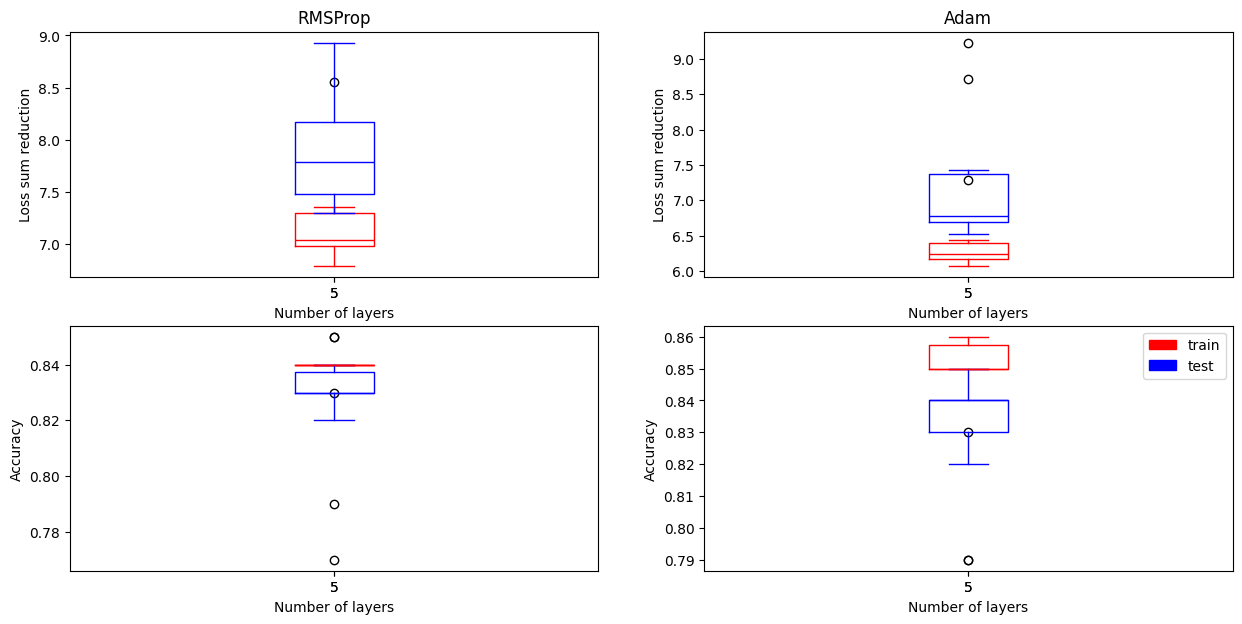

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15,7))
colour=['red','blue']

loss_rmsprop.loc[:, "train_loss"].T.plot.box(ax=ax[0][0],
                          color={'whiskers': colour[0],
                                 'caps': colour[0],
                                 'medians': colour[0],
                                 'boxes': colour[0]}
                          )

loss_rmsprop.loc[:, "test_loss"].T.plot.box(ax=ax[0][0],
                          color={'whiskers': colour[1],
                                 'caps': colour[1],
                                 'medians': colour[1],
                                 'boxes': colour[1]}
                          )

red_patch = mpatches.Patch(color='red', label='train')
blue_patch = mpatches.Patch(color='blue', label='test')
ax[0][0].set_xlabel("Number of layers")
ax[0][0].set_ylabel("Loss sum reduction")
ax[0][0].set_title("RMSProp")
loss_adam.loc[:, "train_loss"].T.plot.box(ax=ax[0][1],
                          color={'whiskers': colour[0],
                                 'caps': colour[0],
                                 'medians': colour[0],
                                 'boxes': colour[0]}
                          )

loss_adam.loc[:, "test_loss"].T.plot.box(ax=ax[0][1],
                          color={'whiskers': colour[1],
                                 'caps': colour[1],
                                 'medians': colour[1],
                                 'boxes': colour[1]}
                          )

red_patch = mpatches.Patch(color='red', label='train')
blue_patch = mpatches.Patch(color='blue', label='test')
ax[0][1].set_xlabel("Number of layers")
ax[0][1].set_ylabel("Loss sum reduction")
ax[0][1].set_title("Adam")

accuracy_rmsprop.loc[:, "train_accuracy"].T.plot.box(ax=ax[1][0],
                          color={'whiskers': colour[0],
                                 'caps': colour[0],
                                 'medians': colour[0],
                                 'boxes': colour[0]}
                          )

accuracy_rmsprop.loc[:, "test_accuracy"].T.plot.box(ax=ax[1][0],
                          color={'whiskers': colour[1],
                                 'caps': colour[1],
                                 'medians': colour[1],
                                 'boxes': colour[1]}
                          )

red_patch = mpatches.Patch(color='red', label='train')
blue_patch = mpatches.Patch(color='blue', label='test')
ax[1][0].set_xlabel("Number of layers")
ax[1][0].set_ylabel("Accuracy")
accuracy_adam.loc[:, "train_accuracy"].T.plot.box(ax=ax[1][1],
                          color={'whiskers': colour[0],
                                 'caps': colour[0],
                                 'medians': colour[0],
                                 'boxes': colour[0]}
                          )

accuracy_adam.loc[:, "test_accuracy"].T.plot.box(ax=ax[1][1],
                          color={'whiskers': colour[1],
                                 'caps': colour[1],
                                 'medians': colour[1],
                                 'boxes': colour[1]}
                          )

red_patch = mpatches.Patch(color='red', label='train')
blue_patch = mpatches.Patch(color='blue', label='test')
ax[1][1].set_xlabel("Number of layers")
ax[1][1].set_ylabel("Accuracy")


plt.legend(handles=[red_patch, blue_patch])

**В среднем Adam показывает себя лучше, по времени работы они +- одинаковые**

### 4.2 Реализация современной функции активации (2 + 2 балла).
Реализуйте одну из активаций, предложенных на лекции или в статье. Например, `Hardswish`. Сравните сеть с вашей активацией и с `ReLU`.

**Дополнительные баллы** вы получите, если функция будет уникальна среди сдавших задание.

In [ ]:
scale=1.0507009873554804934193349852946

alpha = 1.6732632423543772848170429916717


class SeLUFunction(Function):
    @staticmethod
    def forward(ctx, input):
        max_part = torch.maximum(input, torch.as_tensor(0))
        min_part = torch.minimum(alpha * (torch.exp(input) -1), torch.as_tensor(0))
        selu = scale * (max_part + min_part)

        ctx.save_for_backward(max_part, min_part)
        return selu

    @staticmethod
    def backward(ctx, grad_output):
        max_part, min_part = ctx.saved_tensors
        max_part = max_part.clone().detach()
        min_part = min_part.clone().detach()
        max_part[max_part!=0] = 1
        min_part[min_part!=0] += alpha
        return grad_output * scale * (max_part + min_part)

In [ ]:
class SeLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.identity = SeLUFunction.apply


    def forward(self, input):
        return self.identity(input)

In [ ]:
x = torch.rand(5, requires_grad=True).double()

selu = SeLU()

assert gradcheck(selu.to(dtype=torch.float64), x)

In [ ]:
x = torch.rand(5, requires_grad=True).double()
torch_selu = nn.SELU()
our_selu = SeLU()

assert torch.norm(torch_selu(x.float()) - our_selu(x)) < 1e-5

In [ ]:
class Network(nn.Module):
    def __init__(self, input_size=28*28, hidden_layers_size=32, num_layers=5,
                 num_classes=10,
                 p=0.1):
        super().__init__()
        self.perceptron = nn.Sequential(
            nn.Flatten(),
            Linear(input_size, hidden_layers_size),
            SeLU(),
            *[Linear(hidden_layers_size, hidden_layers_size),
            SeLU()] * (num_layers-2),
            Dropout(p),
            Linear(hidden_layers_size, num_classes),
            LogSoftmax(),
        )

    def forward(self, inp):
        return self.perceptron(inp)

    def predict(self, inp):
        return self.forward(inp).argmax(dim=1)

In [ ]:
from joblib import Parallel, delayed


device = "cpu"
num_layers = 5

def get_trials():
    loss_history = {}
    acc_history = {}

    model     = Network(num_layers=num_layers)
    optimizer = Adam(model.parameters())
    criterion = CrossEntropy()
    model.to(device)

    for epoch in range(10):
        loss, acc = perform_epoch(model, train_dataloader, criterion,
                                    optimizer=optimizer, device=device)
        loss_test, acc_test = perform_epoch(model, test_dataloader, criterion, device=device)

    loss_history[num_layers] = {"train_loss": loss, "test_loss": loss_test}
    acc_history[num_layers] = {"train_accuracy": acc, "test_accuracy": acc_test}

    return loss_history, acc_history



trials_selu = Parallel(n_jobs=10)(delayed(get_trials)() for trial in range(1, 11))

In [ ]:
class Network(nn.Module):
    def __init__(self, input_size=28*28, hidden_layers_size=32, num_layers=5,
                 num_classes=10,
                 p=0.1):
        super().__init__()
        self.perceptron = nn.Sequential(
            nn.Flatten(),
            Linear(input_size, hidden_layers_size),
            ReLU(),
            *[Linear(hidden_layers_size, hidden_layers_size),
            ReLU()] * (num_layers-2),
            Dropout(p),
            Linear(hidden_layers_size, num_classes),
            LogSoftmax(),
        )

    def forward(self, inp):
        return self.perceptron(inp)

    def predict(self, inp):
        return self.forward(inp).argmax(dim=1)

In [ ]:
trials_relu = Parallel(n_jobs=10)(delayed(get_trials)() for trial in range(1, 11))

In [ ]:
loss_selu, accuracy_selu = loss_and_accuracy_from_trials(trials_selu)
loss_relu, accuracy_relu = loss_and_accuracy_from_trials(trials_relu)

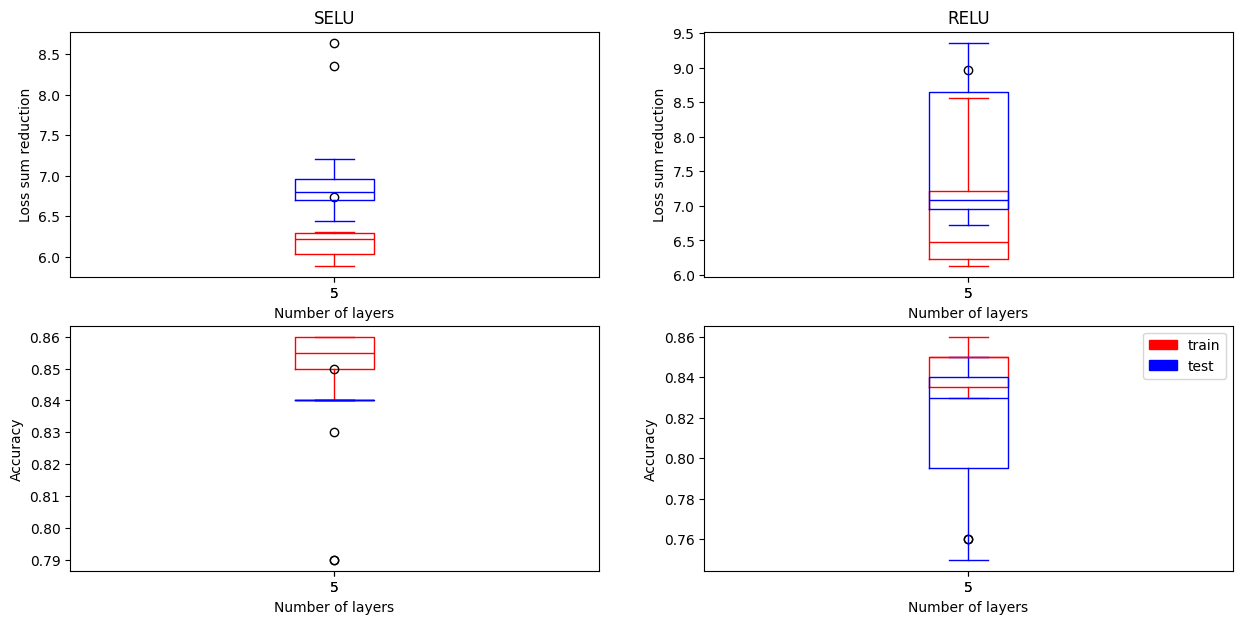

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15,7))
colour=['red','blue']

loss_selu.loc[:, "train_loss"].T.plot.box(ax=ax[0][0],
                          color={'whiskers': colour[0],
                                 'caps': colour[0],
                                 'medians': colour[0],
                                 'boxes': colour[0]}
                          )

loss_selu.loc[:, "test_loss"].T.plot.box(ax=ax[0][0],
                          color={'whiskers': colour[1],
                                 'caps': colour[1],
                                 'medians': colour[1],
                                 'boxes': colour[1]}
                          )

red_patch = mpatches.Patch(color='red', label='train')
blue_patch = mpatches.Patch(color='blue', label='test')
ax[0][0].set_xlabel("Number of layers")
ax[0][0].set_ylabel("Loss sum reduction")
ax[0][0].set_title("SELU")
loss_relu.loc[:, "train_loss"].T.plot.box(ax=ax[0][1],
                          color={'whiskers': colour[0],
                                 'caps': colour[0],
                                 'medians': colour[0],
                                 'boxes': colour[0]}
                          )

loss_relu.loc[:, "test_loss"].T.plot.box(ax=ax[0][1],
                          color={'whiskers': colour[1],
                                 'caps': colour[1],
                                 'medians': colour[1],
                                 'boxes': colour[1]}
                          )

red_patch = mpatches.Patch(color='red', label='train')
blue_patch = mpatches.Patch(color='blue', label='test')
ax[0][1].set_xlabel("Number of layers")
ax[0][1].set_ylabel("Loss sum reduction")
ax[0][1].set_title("RELU")

accuracy_selu.loc[:, "train_accuracy"].T.plot.box(ax=ax[1][0],
                          color={'whiskers': colour[0],
                                 'caps': colour[0],
                                 'medians': colour[0],
                                 'boxes': colour[0]}
                          )

accuracy_selu.loc[:, "test_accuracy"].T.plot.box(ax=ax[1][0],
                          color={'whiskers': colour[1],
                                 'caps': colour[1],
                                 'medians': colour[1],
                                 'boxes': colour[1]}
                          )

red_patch = mpatches.Patch(color='red', label='train')
blue_patch = mpatches.Patch(color='blue', label='test')
ax[1][0].set_xlabel("Number of layers")
ax[1][0].set_ylabel("Accuracy")
accuracy_relu.loc[:, "train_accuracy"].T.plot.box(ax=ax[1][1],
                          color={'whiskers': colour[0],
                                 'caps': colour[0],
                                 'medians': colour[0],
                                 'boxes': colour[0]}
                          )

accuracy_relu.loc[:, "test_accuracy"].T.plot.box(ax=ax[1][1],
                          color={'whiskers': colour[1],
                                 'caps': colour[1],
                                 'medians': colour[1],
                                 'boxes': colour[1]}
                          )

red_patch = mpatches.Patch(color='red', label='train')
blue_patch = mpatches.Patch(color='blue', label='test')
ax[1][1].set_xlabel("Number of layers")
ax[1][1].set_ylabel("Accuracy")


plt.legend(handles=[red_patch, blue_patch])

**SeLU показывает меньшую дисперсию результата среди 10 проведенных экспериментов, при этом качество не уступает ReLU. Таким образом SeLU может рассматриваться как неплохая альтернатива классическому ReLU слою**